# NNDL Week 2

**Name: Shashank Goel**
**Roll no: J011**
**SAP ID: 70092300008**
**Batch: B.Tech Data Science**

# Practical 2 — Make the network earn it

Last week one neuron barely beat a rock. This week we wire many neurons together, and we're going to *feel*, with our own hands, the two things the lecture claimed:

1. **The activation is the whole point.** Rip it out and a 256-neuron network is no smarter than a straight line.
2. **Depth pays.** Arrange the same neurons *deep* instead of *wide* and a problem that was hard becomes easy.

Everything here is ~40 lines of NumPy — no framework, no magic. Run it top to bottom once, then come back and **break things**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

MINT, CORAL, BLUE = "#4FD1C5", "#E8825A", "#8AB4F8"
plt.rcParams["figure.dpi"] = 110

## The data: two shapes we'll torture the network with

Two 2-D toy problems. We use 2-D on purpose — with two inputs we can *draw* the decision boundary and literally watch the network think.

- **Circles** — an inner blob (label 1) inside an outer ring (label 0). No straight line can separate them.
- **Spiral** — two intertwined arms. Fiendish: the boundary has to wind around several times.

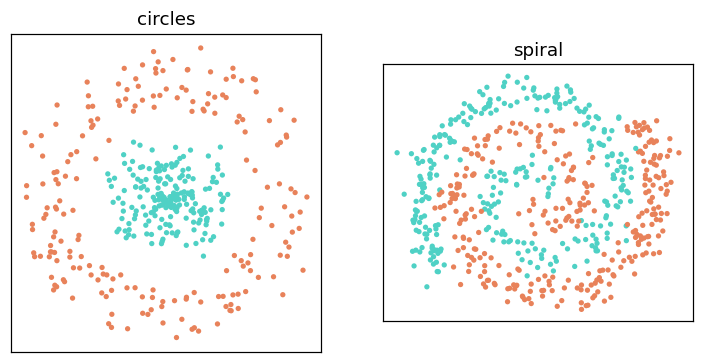

shapes: (2, 400) (1, 400)


In [2]:
def make_circles(n=400, noise=0.08, seed=0):
    r = np.random.default_rng(seed); m = n // 2
    t1 = r.uniform(0, 2*np.pi, m); rad1 = r.uniform(0, 0.9, m)
    inner = np.c_[rad1*np.cos(t1), rad1*np.sin(t1)]
    t2 = r.uniform(0, 2*np.pi, m); rad2 = r.uniform(1.4, 2.2, m)
    outer = np.c_[rad2*np.cos(t2), rad2*np.sin(t2)]
    X = np.vstack([inner, outer]) + r.normal(0, noise, (2*m, 2))
    y = np.r_[np.ones(m), np.zeros(m)]
    idx = r.permutation(2*m)
    return X[idx].T, y[idx].reshape(1, -1)          # X:(2,m)  Y:(1,m)

def make_spiral(n=600, noise=0.18, seed=0, turns=1.6):
    r = np.random.default_rng(seed); m = n // 2
    t = np.sqrt(r.uniform(0, 1, m)) * turns * 2*np.pi
    rad = t / (turns*2*np.pi) * 2.2 + 0.15
    a = np.c_[rad*np.cos(t),        rad*np.sin(t)]
    b = np.c_[rad*np.cos(t+np.pi),  rad*np.sin(t+np.pi)]
    X = np.vstack([a, b]) + r.normal(0, noise, (2*m, 2))
    y = np.r_[np.ones(m), np.zeros(m)]
    idx = r.permutation(2*m)
    return X[idx].T, y[idx].reshape(1, -1)

Xc, Yc = make_circles(seed=0)
Xs, Ys = make_spiral(seed=0)

def scatter(X, Y, ax, title):
    c = np.where(Y.ravel() > 0.5, MINT, CORAL)
    ax.scatter(X[0], X[1], c=c, s=12, edgecolors="none")
    ax.set_title(title); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 4))
scatter(Xc, Yc, a1, "circles"); scatter(Xs, Ys, a2, "spiral")
plt.show()
print("shapes:", Xc.shape, Yc.shape)

## The whole network, from scratch

One dictionary of weights, a forward pass, a backward pass, a step. The `act` argument lets us swap the hidden activation `g` at will — that switch is the star of Part 1.

Read it once: it is *exactly* last week's neuron, wrapped in a loop over layers. The output neuron is always a sigmoid (we still want a probability), so the output blame is still the beautiful `dZ = A - Y`.

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

# each activation g paired with its slope g'
ACT = {
    "relu":     (lambda z: np.maximum(0, z),   lambda z: (z > 0).astype(float)),
    "tanh":     (lambda z: np.tanh(z),         lambda z: 1 - np.tanh(z)**2),
    "sigmoid":  (sigmoid,                      lambda z: sigmoid(z)*(1 - sigmoid(z))),
    "identity": (lambda z: z,                  lambda z: np.ones_like(z)),   # "no bend"
}

def init_params(dims, seed=1, scale=None):
    r = np.random.default_rng(seed); p = {}
    for l in range(1, len(dims)):
        s = scale if scale is not None else np.sqrt(2.0/dims[l-1])   # sensible random start
        p[f"W{l}"] = r.standard_normal((dims[l], dims[l-1])) * s
        p[f"b{l}"] = np.zeros((dims[l], 1))
    return p

def forward(X, p, act="tanh"):
    g, _ = ACT[act]; cache = {"A0": X}; A = X; L = len(p)//2
    for l in range(1, L):                      # hidden layers: score, then squash
        Z = p[f"W{l}"] @ A + p[f"b{l}"]
        A = g(Z); cache[f"Z{l}"] = Z; cache[f"A{l}"] = A
    ZL = p[f"W{L}"] @ A + p[f"b{L}"]           # output layer: always sigmoid
    AL = sigmoid(ZL); cache[f"Z{L}"] = ZL; cache[f"A{L}"] = AL
    return AL, cache

def bce(AL, Y):                                # embarrassment, averaged over the class
    eps = 1e-8
    return -np.mean(Y*np.log(AL+eps) + (1-Y)*np.log(1-AL+eps))

def backward(p, cache, Y, act="tanh"):
    _, gp = ACT[act]; grads = {}; L = len(p)//2; m = Y.shape[1]
    dZ = cache[f"A{L}"] - Y                     # the collapse, at the output
    for l in range(L, 0, -1):
        grads[f"dW{l}"] = (dZ @ cache[f"A{l-1}"].T) / m
        grads[f"db{l}"] = np.sum(dZ, axis=1, keepdims=True) / m
        if l > 1:                               # hand the blame one layer left
            dZ = (p[f"W{l}"].T @ dZ) * gp(cache[f"Z{l-1}"])
    return grads

def update(p, grads, lr):
    for l in range(1, len(p)//2 + 1):
        p[f"W{l}"] -= lr*grads[f"dW{l}"]; p[f"b{l}"] -= lr*grads[f"db{l}"]
    return p

def train(X, Y, dims, act="tanh", lr=0.5, epochs=3000, seed=1, scale=None, snaps=()):
    p = init_params(dims, seed, scale); losses = []; shots = {}
    for e in range(epochs):
        AL, cache = forward(X, p, act); losses.append(bce(AL, Y))
        update(p, backward(p, cache, Y, act), lr)
        if e in snaps: shots[e] = {k: v.copy() for k, v in p.items()}
    return p, losses, shots

def accuracy(X, Y, p, act="tanh"):
    AL, _ = forward(X, p, act)
    return float(np.mean((AL > 0.5) == (Y > 0.5)))

In [4]:
def plot_boundary(X, Y, p, act="tanh", ax=None, title="", res=180):
    if ax is None: _, ax = plt.subplots(figsize=(4, 4))
    lim = 2.8
    xx, yy = np.meshgrid(np.linspace(-lim, lim, res), np.linspace(-lim, lim, res))
    AL, _ = forward(np.c_[xx.ravel(), yy.ravel()].T, p, act)
    ax.contourf(xx, yy, AL.reshape(xx.shape), levels=np.linspace(0, 1, 11),
                cmap="coolwarm_r", alpha=0.55)
    c = np.where(Y.ravel() > 0.5, "#0d5f57", "#8a3a1e")
    ax.scatter(X[0], X[1], c=c, s=9, edgecolors="none")
    ax.set_title(title); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    return ax

## Part 1 — the activation is the whole point

### 💥 Break it #1: rip the bend out

Set every hidden activation to `identity` — i.e. `g(z) = z`, no bend at all. The lecture claimed that stacking *linear* layers collapses to a single line, so **no amount of width can save it**. Let's try to prove the lecture wrong by throwing more and more neurons at the circles.

LINEAR (identity) activation on the circles:


  width=  8  ->  accuracy = 0.570
  width= 64  ->  accuracy = 0.570
  width=256  ->  accuracy = 0.570


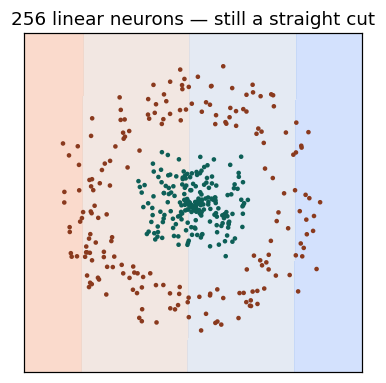

In [5]:
print("LINEAR (identity) activation on the circles:")
for width in [8, 64, 256]:
    p, L, _ = train(Xc, Yc, [2, width, 1], act="identity", lr=0.2, epochs=2000, scale=0.5)
    print(f"  width={width:3d}  ->  accuracy = {accuracy(Xc, Yc, p, 'identity'):.3f}")

p_lin, _, _ = train(Xc, Yc, [2, 256, 1], act="identity", lr=0.2, epochs=2000, scale=0.5)
plot_boundary(Xc, Yc, p_lin, "identity", title="256 linear neurons — still a straight cut")
plt.show()

256 neurons, and the boundary is a *straight line*. Chance is 50%; a rock scores ~57%. The collapse is real: **without the bend, depth and width are decoration.**

### Switch the bend back on

Change one word — `identity` → `tanh` — and watch the boundary wrap itself around the ring.

tanh accuracy: 1.0


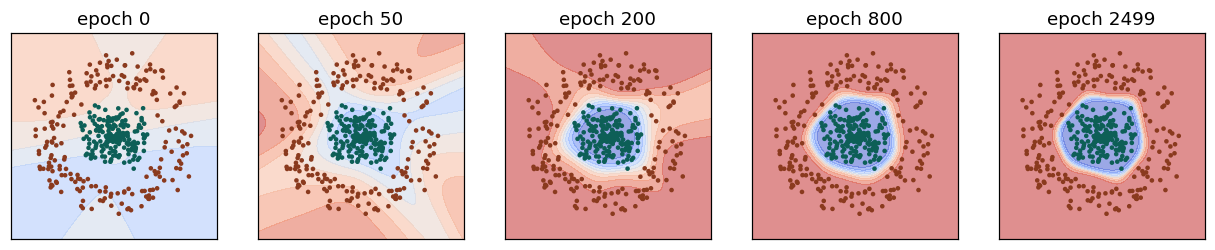

In [6]:
p_tanh, losses, shots = train(Xc, Yc, [2, 16, 1], act="tanh", lr=0.6, epochs=2500,
                              snaps=(0, 50, 200, 800, 2499))
print("tanh accuracy:", accuracy(Xc, Yc, p_tanh, "tanh"))

# film strip: watch the boundary form as the loss falls
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, e in zip(axes, sorted(shots)):
    plot_boundary(Xc, Yc, shots[e], "tanh", ax=ax, title=f"epoch {e}")
plt.show()

### Race the three activations

Same network `[2, 16, 1]`, three different bends. Watch how fast (and how low) each drives the embarrassment.

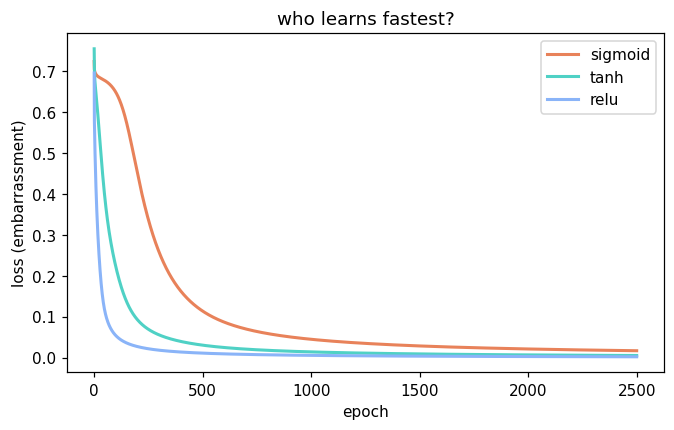

In [7]:
plt.figure(figsize=(7, 4))
for act, col in [("sigmoid", CORAL), ("tanh", MINT), ("relu", BLUE)]:
    _, L, _ = train(Xc, Yc, [2, 16, 1], act=act, lr=0.6, epochs=2500)
    plt.plot(L, color=col, lw=2, label=act)
plt.xlabel("epoch"); plt.ylabel("loss (embarrassment)"); plt.legend(); plt.title("who learns fastest?")
plt.show()

> **Tweak this:** sigmoid usually lags — its flat tails choke the gradient early on. Try bumping `epochs` or `lr` and see whether it ever catches up. Then try a *deeper* net (say `[2, 8, 8, 1]`) with sigmoid vs ReLU and watch the gap widen — that's the vanishing-gradient story warming up.

### 💥 Break it #2: start every weight at zero

`scale=0.0` makes every weight start identical. If the lecture is right about symmetry, all 16 hidden neurons will stay perfect clones and the network will be stuck with the power of one.

In [8]:
for scale, tag in [(0.0, "all zeros"), (None, "small random")]:
    p, L, _ = train(Xc, Yc, [2, 16, 1], act="tanh", lr=0.6, epochs=2500, scale=scale)
    print(f"init = {tag:13s} ->  accuracy = {accuracy(Xc, Yc, p, 'tanh'):.3f}   final loss = {L[-1]:.3f}")

init = all zeros     ->  accuracy = 0.500   final loss = 0.693
init = small random  ->  accuracy = 1.000   final loss = 0.005


Zero-init sits at 0.5 forever — pure coin-flip. Every neuron got the same gradient, took the same step, and never broke rank. The fix was almost silly: start them **tiny and random** so they begin life slightly different. That one line is why `init_params` uses `random.default_rng`.

## Part 2 — does depth actually pay off?

The circles were easy — width or depth, both win. So switch to the nasty **spiral**, and make the fairest possible fight: **the same neuron budget**, arranged wide vs deep.

- wide: `[2, 24, 1]` — 24 hidden neurons in one layer
- deep: `[2, 12, 12, 1]` — the same 24 neurons, split into two layers

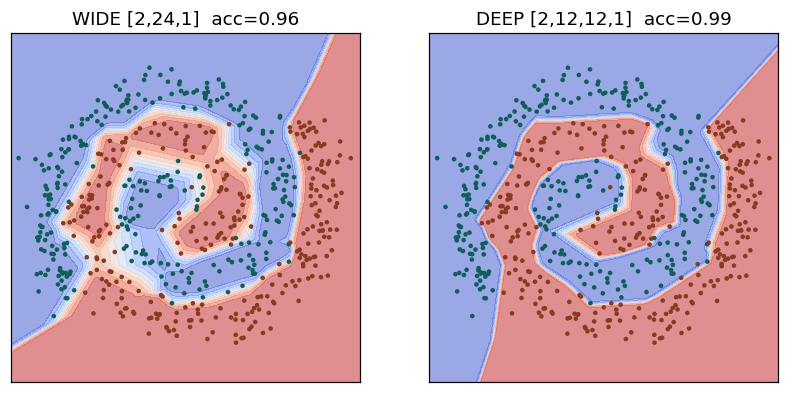

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4.5))
p_wide, _, _ = train(Xs, Ys, [2, 24, 1],     act="relu", lr=0.3, epochs=6000, seed=2)
p_deep, _, _ = train(Xs, Ys, [2, 12, 12, 1], act="relu", lr=0.3, epochs=6000, seed=2)
plot_boundary(Xs, Ys, p_wide, "relu", ax=a1, title=f"WIDE [2,24,1]  acc={accuracy(Xs,Ys,p_wide,'relu'):.2f}")
plot_boundary(Xs, Ys, p_deep, "relu", ax=a2, title=f"DEEP [2,12,12,1]  acc={accuracy(Xs,Ys,p_deep,'relu'):.2f}")
plt.show()

Same 24 neurons. The deep arrangement winds cleanly around the spiral; the wide one leaves ragged mistakes. **Depth spent the same budget better** — exactly the "exponentially cheaper" claim, in miniature.

### Peek at what the first layer built

Each hidden neuron in layer 1 draws one straight line in the input space (where its score `w·x + b` flips sign). The network isn't given these — it *invents* a set of oriented cuts, then later layers glue them into the curved boundary. Here are the lines the first layer chose:

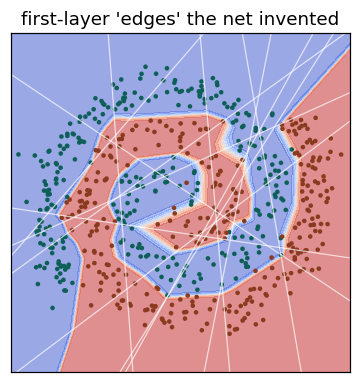

In [10]:
ax = plot_boundary(Xs, Ys, p_deep, "relu", title="first-layer 'edges' the net invented")
W1, b1 = p_deep["W1"], p_deep["b1"]
xline = np.linspace(-2.8, 2.8, 50)
for i in range(W1.shape[0]):
    w0, w1 = W1[i]; bb = b1[i, 0]
    if abs(w1) > 1e-6:
        ax.plot(xline, -(w0*xline + bb)/w1, color="white", lw=0.8, alpha=0.7)
ax.set_ylim(-2.8, 2.8)
plt.show()

Those white lines are the network's raw vocabulary — its "edges." Deeper layers compose them into parts, and parts into the whole spiral. Nobody programmed a single one.

### 💥 Break it #3: hand the network a mis-shaped weight

The #1 real-world bug is a matrix with the wrong shape. `W1` should be `(hidden, 2)`. Give it `(hidden, 3)` and read exactly what NumPy says — so the error stops being scary.

In [11]:
try:
    Wbad = np.random.randn(5, 3)     # expects (5, 2) to meet 2-D inputs
    _ = Wbad @ Xs
except ValueError as e:
    print("ValueError:", e)
    print("\nRead it: the '3' can't meet the '2'. Inner dimensions must match.")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

Read it: the '3' can't meet the '2'. Inner dimensions must match.


## Now go break it yourself

- **Widen the gap:** crank `turns` in `make_spiral` to 2.2 and re-run the wide-vs-deep fight. Watch the wide net fall apart while the deep one holds.
- **Starve it:** shrink both nets to a 6-neuron budget (`[2,6,1]` vs `[2,3,3,1]`). Where does depth's edge show up first?
- **Over-bend it:** stack `[2, 30, 30, 30, 1]` on the *circles*. Does a boundary that should be a simple ring start looking lumpy? (That's overfitting — foreshadowing the next arc.)
- **Kill the gradient:** make a deep net all-`sigmoid` and watch the early layers barely move. That's the vanishing gradient we were warned about.

---

**One-line takeaway:** a layer of neurons only has power because of the bend between them, and stacking those bends deep is how the same neurons buy a far richer boundary — which is the whole reason the field is called *deep* learning.

- **Widen the gap:** crank `turns` in `make_spiral` to 2.2 and re-run the wide-vs-deep fight. Watch the wide net fall apart while the deep one holds.

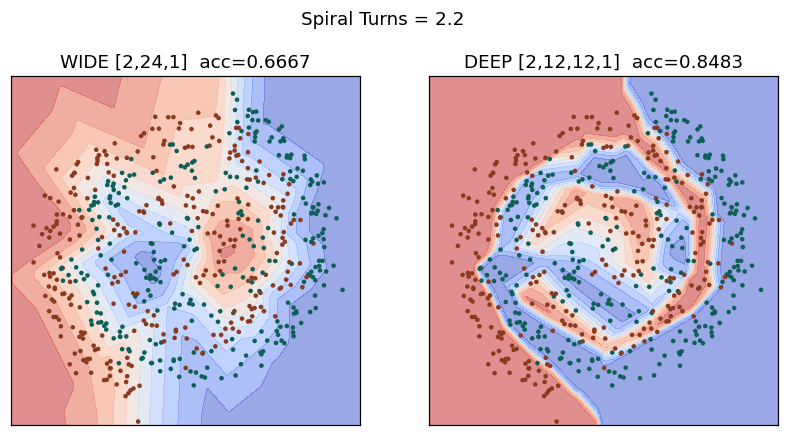

Wide ANN acc: 0.6667
Deep ANN acc: 0.8483


In [12]:
Xs2, Ys2 = make_spiral(seed=0, turns=2.2)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4.5))
p_wide2, _, _ = train(Xs2, Ys2, [2, 24, 1],     act="relu", lr=0.3, epochs=6000, seed=2)
p_deep2, _, _ = train(Xs2, Ys2, [2, 12, 12, 1], act="relu", lr=0.3, epochs=6000, seed=2)
plot_boundary(Xs2, Ys2, p_wide2, "relu", ax=a1, title=f"WIDE [2,24,1]  acc={accuracy(Xs2,Ys2,p_wide2,'relu'):.4f}")
plot_boundary(Xs2, Ys2, p_deep2, "relu", ax=a2, title=f"DEEP [2,12,12,1]  acc={accuracy(Xs2,Ys2,p_deep2,'relu'):.4f}")
plt.suptitle("Spiral Turns = 2.2")
plt.show()
print(f"Wide ANN acc: {accuracy(Xs2,Ys2,p_wide2,'relu'):.4f}")   
print(f"Deep ANN acc: {accuracy(Xs2,Ys2,p_deep2,'relu'):.4f}")

- **Starve it:** shrink both nets to a 6-neuron budget (`[2,6,1]` vs `[2,3,3,1]`). Where does depth's edge show up first?

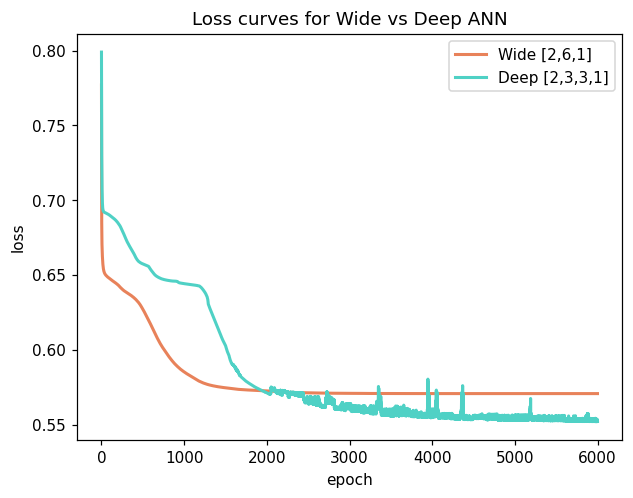

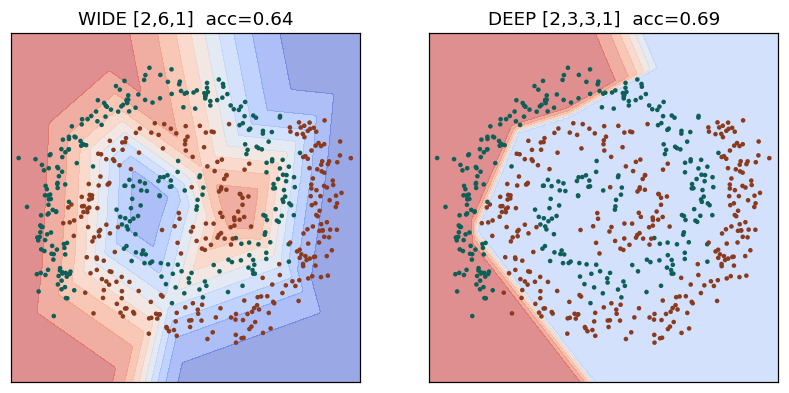

Wide ANN acc: 0.6400
Deep ANN acc: 0.6883


In [ ]:
nn1_p, nn1_l, _ = train(Xs2, Ys2, [2, 6, 1], act="relu", lr=0.3, epochs=6000, seed=2)
nn2_p, nn2_l, _ = train(Xs2, Ys2, [2, 3, 3, 1], act="relu", lr=0.3, epochs=6000, seed=2)

plt.plot(nn1_l, color=CORAL, lw=2, label='Wide [2,6,1]')
plt.plot(nn2_l, color=MINT, lw=2, label='Deep [2,3,3,1]')
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Loss curves for Wide vs Deep ANN")
plt.show()

nn1_acc = accuracy(Xs2, Ys2, nn1_p, 'relu')
nn2_acc = accuracy(Xs2, Ys2, nn2_p, 'relu')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4.5))
plot_boundary(Xs, Ys, nn1_p, "relu", ax=a1, title=f"WIDE [2,6,1]  acc={nn1_acc:.2f}")
plot_boundary(Xs, Ys, nn2_p, "relu", ax=a2, title=f"DEEP [2,3,3,1]  acc={nn2_acc:.2f}")
plt.show()
print(f"Wide ANN acc: {nn1_acc:.4f}")
print(f"Deep ANN acc: {nn2_acc:.4f}")

# The wide network starts showing its depth's (loss) edge first. 

- **Over-bend it:** stack `[2, 30, 30, 30, 1]` on the *circles*. Does a boundary that should be a simple ring start looking lumpy? (That's overfitting — foreshadowing the next arc.)

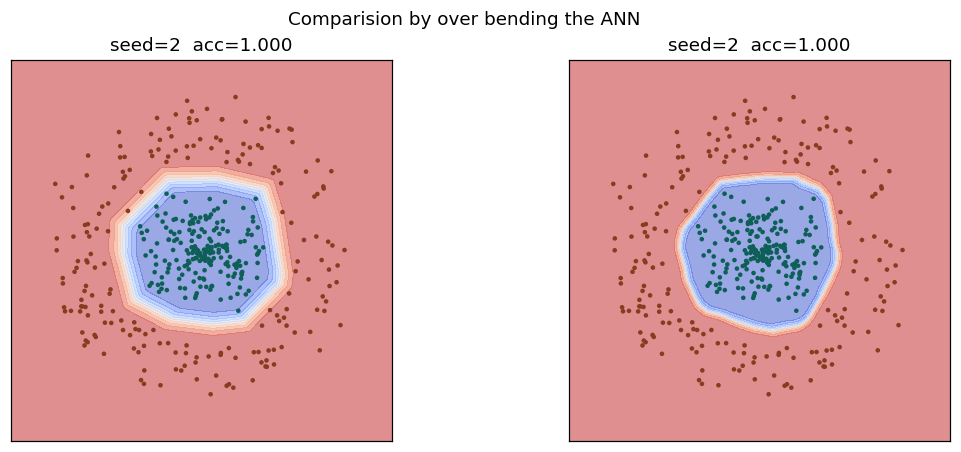

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
p_circle_1, L_over_1, _ = train(Xc, Yc, [2, 10, 1], act="relu", lr=0.3, epochs=1000, seed=2)
p_circle_2, L_over_2, _ = train(Xc, Yc, [2, 30, 30, 30, 1], act="relu", lr=0.3, epochs=1000, seed=2)
plot_boundary(Xc, Yc, p_circle_1, "relu", ax=axes[0],
                title=f"seed={2}  acc={accuracy(Xc, Yc, p_circle_1, 'relu'):.3f}")
plot_boundary(Xc, Yc, p_circle_2, "relu", ax=axes[1],
                title=f"seed={2}  acc={accuracy(Xc, Yc, p_circle_2, 'relu'):.3f}")
plt.suptitle("Comparision by over bending the ANN")
plt.show()

# Yes, the simple ring starts looking lumpy and overfitting on the model.

- **Kill the gradient:** make a deep net all-`sigmoid` and watch the early layers barely move. That's the vanishing gradient we were warned about.

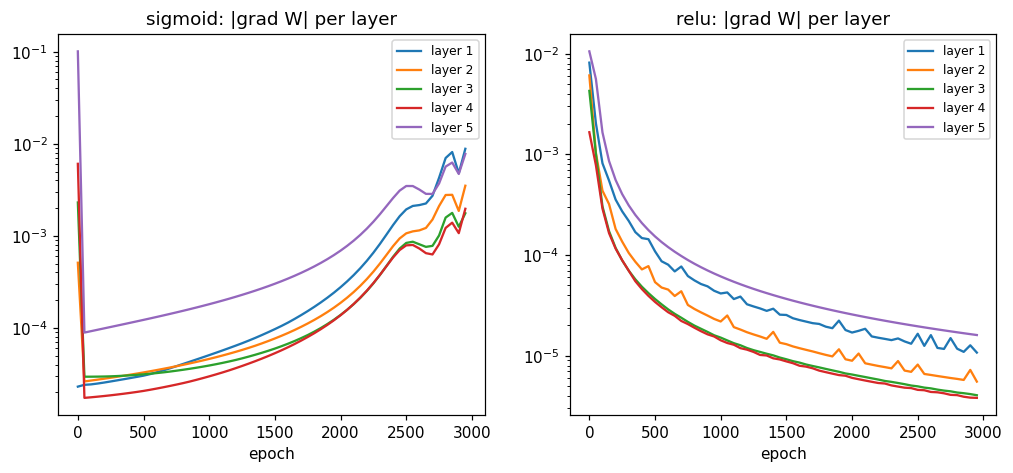

sigmoid  layer-1 grad: start=2.30e-05  end=8.83e-03   final acc=0.988
sigmoid  layer-4 grad: start=6.06e-03  end=1.97e-03
relu     layer-1 grad: start=8.17e-03  end=1.08e-05   final acc=1.000
relu     layer-4 grad: start=1.66e-03  end=3.82e-06


In [ ]:
def train_grad_track(X, Y, dims, act="sigmoid", lr=0.5, epochs=3000, seed=1, every=50):
    p = init_params(dims, seed)
    L = len(p) // 2
    history = {l: [] for l in range(1, L + 1)}
    epochs_list = []
    for e in range(epochs):
        AL, cache = forward(X, p, act)
        grads = backward(p, cache, Y, act)
        if e % every == 0:
            epochs_list.append(e)
            for l in range(1, L + 1):
                history[l].append(np.mean(np.abs(grads[f"dW{l}"])))
        update(p, grads, lr)
    return p, epochs_list, history

dims_deep = [2, 8, 8, 8, 8, 1]
p_sig,  e_sig,  h_sig  = train_grad_track(Xc, Yc, dims_deep, act="sigmoid", lr=0.5, epochs=3000)
p_relu, e_relu, h_relu = train_grad_track(Xc, Yc, dims_deep, act="relu",    lr=0.5, epochs=3000)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.5))
for l in h_sig:
    a1.plot(e_sig, h_sig[l], label=f"layer {l}")
a1.set_yscale("log") 
a1.set_title("sigmoid: |grad W| per layer")
a1.set_xlabel("epoch")
a1.legend(fontsize=8)

for l in h_relu:
    a2.plot(e_relu, h_relu[l], label=f"layer {l}")
a2.set_yscale("log")
a2.set_title("relu: |grad W| per layer")
a2.set_xlabel("epoch")
a2.legend(fontsize=8)
plt.show()

print(f"sigmoid  layer-1 grad: start={h_sig[1][0]:.2e}  end={h_sig[1][-1]:.2e}   final acc={accuracy(Xc,Yc,p_sig,'sigmoid'):.3f}")
print(f"sigmoid  layer-4 grad: start={h_sig[4][0]:.2e}  end={h_sig[4][-1]:.2e}")
print(f"relu     layer-1 grad: start={h_relu[1][0]:.2e}  end={h_relu[1][-1]:.2e}   final acc={accuracy(Xc,Yc,p_relu,'relu'):.3f}")
print(f"relu     layer-4 grad: start={h_relu[4][0]:.2e}  end={h_relu[4][-1]:.2e}")

### This ipynb is submitted by Shashank Goel